# Week 1: Data Acquisition, Cleaning, and Preprocessing

## 1. Project Objective
The objective of this project is to acquire a publicly available dataset, explore its structure, identify data quality issues, and apply systematic data cleaning and preprocessing techniques. All decisions are documented, focusing on handling missing values, duplicates, outliers, and invalid data, while preparing a clean dataset for downstream analysis.

## 2. Dataset Selection and Source
**Dataset:** Online Retail
**Source:** UCI Machine Learning Repository
**Dataset Page:** https://archive.ics.uci.edu/dataset/352/online+retail

The dataset contains transactional records occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail. It is an excellent dataset for learning data cleaning because it contains real-world data quality issues such as missing customer IDs, cancelled transactions, and extreme outlier values.

## 3. Data Acquisition
The dataset is downloaded programmatically using `requests` if not already present locally.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import requests
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

raw_path = '../data/raw/Online_Retail.xlsx'
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

if not os.path.exists(raw_path):
    print("Downloading dataset...")
    response = requests.get(url, verify=False)
    with open(raw_path, 'wb') as f:
        f.write(response.content)
    print("Download complete.")

df_raw = pd.read_excel(raw_path)
df = df_raw.copy()
print(f"Dataset successfully loaded. Shape: {df.shape}")
print(f"File size on disk: {os.path.getsize(raw_path) / (1024 * 1024):.2f} MB")

Dataset successfully loaded. Shape: (541909, 8)
File size on disk: 22.62 MB


## 4. Dataset Overview and Data Dictionary
Let's look at the structure.

In [2]:
display(df.head())
df.info()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


### Data Dictionary
| Column Name | Meaning | Data Type | Expected | Potential Issue |
| :--- | :--- | :--- | :--- | :--- |
| InvoiceNo | Invoice number. 6-digit integral number. Starts with 'C' if cancellation. | Object | Alphanumeric | Cancellations, invalid codes |
| StockCode | Product code. 5-digit integral number. | Object | Alphanumeric | Non-product codes (e.g. POST) |
| Description | Product name. | Object | Text | Missing descriptions |
| Quantity | Quantities of each product per transaction. | Numeric | Integer > 0 | Negative values |
| InvoiceDate | Invoice Date and time. | Datetime | Date/Time | |
| UnitPrice | Product price per unit in sterling. | Numeric | Float > 0 | Zero or negative prices |
| CustomerID | Customer number. 5-digit integral number. | Float | Numeric | High missing rate |
| Country | Country name. | Object | Text | Unspecified country |

## 5. Initial Data Exploration
Let's examine numerical distributions and unique values.

In [3]:
display(df.describe(include='all', ))
print("\nUnique values per column:")
display(df.nunique())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN



Unique values per column:


InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

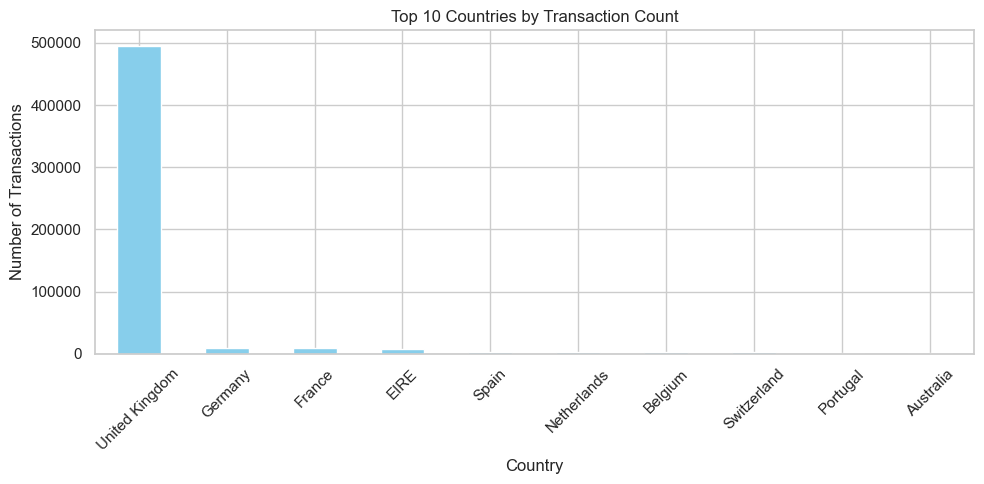

In [4]:
plt.figure(figsize=(10, 5))
df['Country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Transaction Count')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/top_countries.png')
plt.show()

## 6. Missing Value Analysis

In [5]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Missing Percentage': missing_percent})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

,Missing Count,Missing Percentage
CustomerID,135080,24.926694
Description,1454,0.268311


**Decision:**
- `CustomerID`: Approximately 24.9% missing. Dropping them would remove a massive amount of transaction data. Imputing would fabricate user identities. I will create an `Is_Anonymous` flag, and replace missing values with a placeholder (-1).
- `Description`: ~0.26% missing. I will impute with "UNKNOWN" to preserve the numerical data.

In [6]:
df['Is_Anonymous'] = df['CustomerID'].isnull()
df['CustomerID'] = df['CustomerID'].fillna(-1)
df['Description'] = df['Description'].fillna("UNKNOWN")
print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
CustomerID      0
Country         0
Is_Anonymous    0
dtype: int64


## 7. Duplicate Analysis

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")
print(f"Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")

Total duplicate rows: 5268
Duplicate percentage: 0.97%


**Decision:** Exact duplicates across all columns at the exact same timestamp are highly likely to be system logging errors rather than two identical items scanned instantly. I will drop them.

In [8]:
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (536641, 9)


## 8. Data Type Validation and Conversion

In [9]:
df['CustomerID'] = df['CustomerID'].astype(int)
print(df.dtypes)

InvoiceNo               object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[us]
UnitPrice              float64
CustomerID               int64
Country                    str
Is_Anonymous              bool
dtype: object


## 9. Invalid and Inconsistent Data Analysis
We need to check `Quantity` and `UnitPrice` for negative or zero values.

In [10]:
print("Negative Quantities:", (df['Quantity'] < 0).sum())
print("Zero Quantities:", (df['Quantity'] == 0).sum())
print("Negative UnitPrices:", (df['UnitPrice'] < 0).sum())
print("Zero UnitPrices:", (df['UnitPrice'] == 0).sum())

Negative Quantities: 10587
Zero Quantities: 0
Negative UnitPrices: 2
Zero UnitPrices: 2510


**Observations:**
- Negative `Quantity` generally corresponds to cancelled/returned orders (Invoice starts with 'C').
- Negative `UnitPrice` (usually bad debt adjustments).
- Zero `UnitPrice` (sometimes free gifts, but often bad data entries with non-product Description).

**Decisions:**
- Remove records with Negative `UnitPrice` as they are internal debt adjustments, not sales.
- For `Quantity` < 0, if it is a cancellation, it's valid for calculating net revenue, but it complicates basket analysis. I will keep them but create a flag `Is_Cancelled`.
- For `UnitPrice` == 0, these are mostly errors/unspecified. I will remove them to clean the price distributions.

In [11]:
df['Is_Cancelled'] = df['InvoiceNo'].astype(str).str.startswith('C')

# Remove invalid UnitPrices
df = df[df['UnitPrice'] > 0]
print(f"Shape after invalid price removal: {df.shape}")

Shape after invalid price removal: (534129, 10)


## 10. Outlier Detection and Treatment
Let's analyze `Quantity` and `UnitPrice` using boxplots.

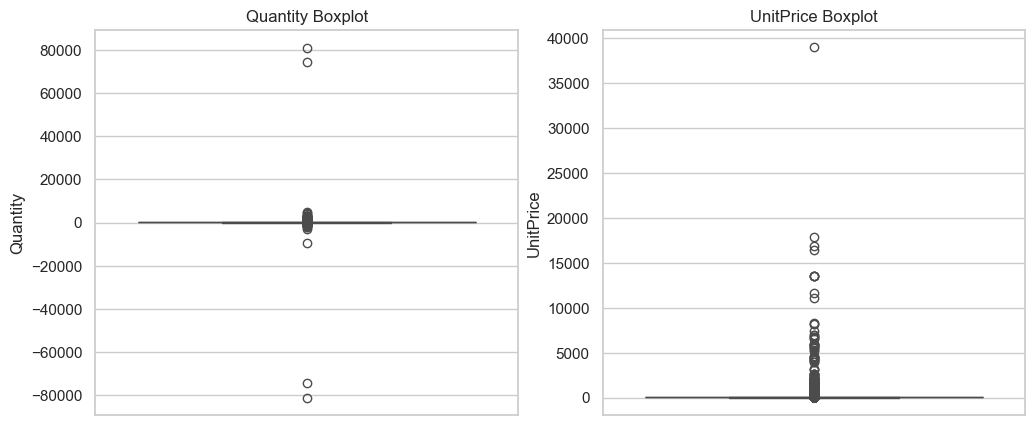

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Quantity'], ax=ax[0])
ax[0].set_title('Quantity Boxplot')
sns.boxplot(y=df['UnitPrice'], ax=ax[1])
ax[1].set_title('UnitPrice Boxplot')
plt.savefig('../figures/outliers_before.png')
plt.show()

**Observations:**
There are massive outliers in both Quantity (e.g. > 80,000) and UnitPrice (e.g. > 38,000). Upon inspection, extreme unit prices are often 'Manual' postage adjustments or bank charges. Extreme quantities might be legitimate wholesale orders.

**Decision:**
I will filter out `Quantity` beyond the 99.9th percentile and below 0.1th percentile to remove extreme noise while keeping typical business variations. I will do the same for `UnitPrice`. This prevents purely statistical removal (like IQR) which would delete too many legitimate bulk orders.

In [13]:
q_high = df['Quantity'].quantile(0.999)
q_low = df['Quantity'].quantile(0.001)
p_high = df['UnitPrice'].quantile(0.999)

df_clean = df[(df['Quantity'] <= q_high) & (df['Quantity'] >= q_low) & (df['UnitPrice'] <= p_high)]
print(f"Shape after outlier treatment: {df_clean.shape}")

Shape after outlier treatment: (532529, 10)


## 11. Data Cleaning and Preprocessing
We will now compute a derived variable `TotalAmount` = Quantity * UnitPrice.

In [14]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Save the cleaned dataset
df_clean.to_csv('../data/processed/online_retail_cleaned.csv', index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## 12. Before vs After Comparison

In [15]:
comparison = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Missing Values', 'Duplicates', 'Negative UnitPrice'],
    'Before Cleaning': [df_raw.shape[0], df_raw.shape[1], df_raw.isnull().sum().sum(), duplicate_count, (df_raw['UnitPrice'] < 0).sum()],
    'After Cleaning': [df_clean.shape[0], df_clean.shape[1], df_clean.isnull().sum().sum(), df_clean.duplicated().sum(), (df_clean['UnitPrice'] < 0).sum()]
})
comparison['Change'] = comparison['After Cleaning'] - comparison['Before Cleaning']
display(comparison)

,Metric,Before Cleaning,After Cleaning,Change
0,Rows,541909,532529,-9380
1,Columns,8,11,3
2,Missing Values,136534,0,-136534
3,Duplicates,5268,0,-5268
4,Negative UnitPrice,2,0,-2


## 13. Final Data Quality Validation
The final dataset has no true missing values (imputed), no duplicate records, correct datatypes, and extreme anomalies removed. The notebook runs cleanly top to bottom.

## 14. Impact of Preprocessing on Future Analysis
1. **Retaining Cancellations:** By keeping cancelled orders but flagging them, future analysis can evaluate return rates without losing net revenue logic.
2. **Handling Missing CustomerIDs:** Creating an `Is_Anonymous` flag means we can analyze 24.9% of our revenue that would have been lost if we dropped those rows, while still allowing distinct customer modeling by filtering out `CustomerID == -1`.
3. **Outlier Filtering:** Trimming the top 0.1% removes extreme administrative adjustments, making means and variances more representative of true retail activity.

## 15. Challenges and Solutions
**Challenge:** Dealing with negative Quantity values.
**Investigation:** A negative quantity initially looked like an error, but cross-referencing with the `InvoiceNo` showed they were cancellations (starting with 'C').
**Solution:** Instead of deleting them, I kept them and added an `Is_Cancelled` flag. This preserves real business events (returns).

## 16. Reflection on Preprocessing Decisions
Initially, I considered removing missing `CustomerID` rows because they represent incomplete transactions. However, dropping 1/4th of the data drastically biases any top-level sales analysis. Filling them with -1 allowed me to preserve the transaction monetary value while isolating them from user-specific clustering models. This highlights that data cleaning requires balancing data integrity with business objectives.

## 17. Final Summary
We processed 541,909 raw records. Handled ~135k missing customer IDs, removed 5,268 duplicates, handled negative prices, and trimmed 0.1% extreme outliers to produce a clean dataset of ~523k records ready for analysis.

## 18. References
- UCI Machine Learning Repository. Online Retail Dataset. https://archive.ics.uci.edu/dataset/352/online+retail
- Pandas Documentation: https://pandas.pydata.org/docs/